<a href="https://colab.research.google.com/github/NaziaAfreen015/CSC791-DLBA/blob/main/bars_and_charts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import json
import re
from pathlib import Path
from typing import List, Dict, Any, Optional

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [55]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## New Bars

### Helpers

In [68]:
# -----------------------------
# Helpers
# -----------------------------
def load_result_json(path):
    """Load result JSON file."""
    with open(path, "r") as f:
        return json.load(f)


def normalize_text(s):
    return re.sub(r"[^a-z0-9]+", " ", str(s).lower()).strip()


def find_table(tables, title_keywords):
    """
    Find a table whose title contains all given keywords.
    Works for your list-of-dicts JSON format:
    [
      {"title": "...", "headers": [...], "data": [...]},
      ...
    ]
    """
    title_keywords = [normalize_text(k) for k in title_keywords]

    for table in tables:
        title = normalize_text(table.get("title", ""))
        if all(k in title for k in title_keywords):
            return table

    available = [t.get("title", "") for t in tables if isinstance(t, dict)]
    raise ValueError(
        f"Could not find table with keywords {title_keywords}.\n"
        f"Available tables:\n" + "\n".join(available)
    )


def table_to_df(table):
    """Convert one JSON table block to a pandas DataFrame."""
    return pd.DataFrame(table["data"], columns=table["headers"])


def parse_percent_or_float(x):
    """
    Converts:
      '20%' -> 0.20
      '20.0' -> 0.20 if value > 1 and likely percent
      '0.2' -> 0.2
      'Dense' -> 0.0
    """
    if isinstance(x, str):
        x_clean = x.strip()

        if x_clean.lower() == "dense":
            return 0.0

        if "%" in x_clean:
            return float(x_clean.replace("%", "")) / 100.0

        match = re.search(r"\d+(\.\d+)?", x_clean)
        if match:
            val = float(match.group())
            return val / 100.0 if val > 1 else val

    val = float(x)
    return val / 100.0 if val > 1 else val


def model_to_sparsity(model_name):
    """
    Handles:
      Dense
      Dense (Uncompressed)
      Pruned 20%
      Pruned (20% Sparsity)
      20%
      20.0
    """
    s = str(model_name).strip().lower()

    if "dense" in s or "uncompressed" in s:
        return 0.0

    match = re.search(r"\d+(\.\d+)?", s)
    if not match:
        raise ValueError(f"Could not parse sparsity from model name: {model_name}")

    val = float(match.group())
    return val / 100.0 if val > 1 else val


def wide_metric_table_to_long(
    df,
    model_col=None,
    value_name="value",
):
    """
    Converts a wide table like:

      Model Variant | 0.0078 | 0.0156 | 0.0313
      Dense         | ...
      Pruned 20%    | ...

    into long format:

      sparsity | epsilon | value | model
    """
    if model_col is None:
        model_col = df.columns[0]

    long_df = df.melt(
        id_vars=[model_col],
        var_name="epsilon",
        value_name=value_name,
    )

    long_df["model"] = long_df[model_col].astype(str)
    long_df["sparsity"] = long_df[model_col].apply(model_to_sparsity)
    long_df["epsilon"] = long_df["epsilon"].apply(parse_epsilon)
    long_df[value_name] = long_df[value_name].astype(float)

    return long_df[["model", "sparsity", "epsilon", value_name]]


def clean_accuracy_table_to_df(df):
    """
    Converts clean accuracy table:

      Model Type | Clean Accuracy
      Dense      | 0.9155
      Pruned 20% | 0.9185

    into:

      model | sparsity | clean_accuracy
    """
    model_col = df.columns[0]
    acc_col = df.columns[1]

    out = df.copy()
    out["model"] = out[model_col].astype(str)
    out["sparsity"] = out[model_col].apply(model_to_sparsity)
    out["clean_accuracy"] = out[acc_col].astype(float)

    return out[["model", "sparsity", "clean_accuracy"]]

def parse_epsilon(col_name):
    """
    Handles:
      0.0078
      '0.0078'
      'Pruned Sparsity 0.0078'
    """
    match = re.search(r"\d+\.\d+", str(col_name))
    if not match:
        raise ValueError(f"Could not parse epsilon from column name: {col_name}")
    return float(match.group())

def wide_transfer_table_to_long(df, value_name):
    sparsity_col = df.columns[0]

    long_df = df.melt(
        id_vars=[sparsity_col],
        var_name="epsilon",
        value_name=value_name,
    )

    long_df["sparsity"] = long_df[sparsity_col].apply(model_to_sparsity)
    long_df["epsilon"] = long_df["epsilon"].apply(parse_epsilon)
    long_df[value_name] = long_df[value_name].astype(float)

    return long_df[["sparsity", "epsilon", value_name]]

### Plotting Functions

In [69]:
# -----------------------------
# Plotting functions
# -----------------------------
def plot_metric_vs_sparsity(
    df,
    metric_col,
    ylabel,
    title,
    output_path=None,
    percent_y=True,
):
    """
    Plots one line per epsilon:
      x-axis: sparsity
      y-axis: metric_col
    """
    plt.figure(figsize=(8, 5))

    for eps, group in df.groupby("epsilon"):
        group = group.sort_values("sparsity")
        plt.plot(
            group["sparsity"] * 100,
            group[metric_col] * 100 if percent_y else group[metric_col],
            marker="o",
            label=f"ε={eps:g}",
        )

    plt.xlabel("Sparsity (%)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Epsilon")
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()


def make_plots(json_path, model_name, dataset_name, output_dir=None):
    """
    Full pipeline:
      - loads JSON
      - extracts attack success rate
      - computes adversarial accuracy drop
      - plots both
    """
    attack_df, drop_df = extract_attack_and_drop_data(json_path)

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        attack_out = output_dir / "attack_success_rate_vs_sparsity.png"
        drop_out = output_dir / "adversarial_accuracy_drop_vs_sparsity.png"
    else:
        attack_out = None
        drop_out = None

    plot_metric_vs_sparsity(
        attack_df,
        metric_col="attack_success_rate",
        ylabel="Attack Success Rate (%)",
        title=f"{model_name}-{dataset_name}:Attack Success Rate vs Sparsity Across Epsilons",
        output_path=attack_out,
    )

    plot_metric_vs_sparsity(
        drop_df,
        metric_col="adversarial_accuracy_drop",
        ylabel="Adversarial Accuracy Drop (%)",
        title=f"{model_name}-{dataset_name}:Adversarial Accuracy Drop vs Sparsity Across Epsilons",
        output_path=drop_out,
    )

    return attack_df, drop_df




### Extraction Function

In [70]:

# -----------------------------
# Main extraction function
# -----------------------------
def extract_attack_and_drop_data(json_path):
    """
    Extracts:
      1. attack success rate vs sparsity across epsilons
      2. adversarial accuracy drop vs sparsity across epsilons

    Assumes your JSON has tables for:
      - Attack success rate
      - Adversarial accuracy
      - Clean Accuracy by Model
    """
    tables = load_result_json(json_path)

    attack_table = find_table(tables, ["attack", "success", "rate"])
    adv_acc_table = find_table(tables, ["adversarial", "accuracy", "same"])
    clean_acc_table = find_table(tables, ["clean", "accuracy"])

    attack_df = wide_metric_table_to_long(
        table_to_df(attack_table),
        value_name="attack_success_rate",
    )

    adv_acc_df = wide_metric_table_to_long(
        table_to_df(adv_acc_table),
        value_name="adversarial_accuracy",
    )

    clean_df = clean_accuracy_table_to_df(table_to_df(clean_acc_table))

    drop_df = adv_acc_df.merge(
        clean_df[["sparsity", "clean_accuracy"]],
        on="sparsity",
        how="left",
    )

    drop_df["adversarial_accuracy_drop"] = (
        drop_df["clean_accuracy"] - drop_df["adversarial_accuracy"]
    )

    return attack_df, drop_df




In [71]:
# -----------------------------
# Transfer extraction
# -----------------------------
def find_table_by_title_contains(tables, required_text):
    required_text = normalize_text(required_text)

    for table in tables:
        title = normalize_text(table.get("title", ""))
        if required_text in title:
            return table

    available = [t.get("title", "") for t in tables if isinstance(t, dict)]
    raise ValueError(
        f"Could not find table containing title: {required_text}\n"
        f"Available tables:\n" + "\n".join(available)
    )
def extract_transfer_data(json_path):
    tables = load_result_json(json_path)

    # dense_to_pruned_transfer_table = find_table_by_title_contains(
    #     tables,
    #     "Transferability Dense Pruned"
    # )

    # pruned_to_dense_transfer_table = find_table_by_title_contains(
    #     tables,
    #     "Transferability Pruned Dense"
    # )

    dense_to_pruned_adv_acc_table = find_table_by_title_contains(
        tables,
        "Target adversarial accuracy under transfer Dense Pruned"
    )

    pruned_to_dense_adv_acc_table = find_table_by_title_contains(
        tables,
        "Target adversarial accuracy under transfer Pruned Dense"
    )

    # dense_to_pruned_transfer_df = wide_transfer_table_to_long(
    #     table_to_df(dense_to_pruned_transfer_table),
    #     value_name="transfer_attack_success_rate",
    # )

    # pruned_to_dense_transfer_df = wide_transfer_table_to_long(
    #     table_to_df(pruned_to_dense_transfer_table),
    #     value_name="transfer_attack_success_rate",
    # )

    dense_to_pruned_adv_acc_df = wide_transfer_table_to_long(
        table_to_df(dense_to_pruned_adv_acc_table),
        value_name="target_adversarial_accuracy",
    )

    pruned_to_dense_adv_acc_df = wide_transfer_table_to_long(
        table_to_df(pruned_to_dense_adv_acc_table),
        value_name="target_adversarial_accuracy",
    )

    clean_acc_table = find_table(tables, ["clean", "accuracy"])
    clean_df = clean_accuracy_table_to_df(table_to_df(clean_acc_table))

    # Dense → Pruned:
    # target model is pruned, so clean accuracy varies by sparsity
    dense_to_pruned_adv_acc_df = dense_to_pruned_adv_acc_df.merge(
        clean_df[["sparsity", "clean_accuracy"]],
        on="sparsity",
        how="left",
    )

    dense_to_pruned_adv_acc_df["adversarial_accuracy_drop_under_transfer"] = (
        dense_to_pruned_adv_acc_df["clean_accuracy"]
        - dense_to_pruned_adv_acc_df["target_adversarial_accuracy"]
    )

    # Pruned → Dense:
    # target model is dense, so use dense clean accuracy for every row
    dense_clean_accuracy = clean_df.loc[
        clean_df["sparsity"] == 0.0,
        "clean_accuracy"
    ].iloc[0]

    pruned_to_dense_adv_acc_df["clean_accuracy"] = dense_clean_accuracy

    pruned_to_dense_adv_acc_df["adversarial_accuracy_drop_under_transfer"] = (
        pruned_to_dense_adv_acc_df["clean_accuracy"]
        - pruned_to_dense_adv_acc_df["target_adversarial_accuracy"]
    )

    return {
        # "dense_to_pruned_transfer": dense_to_pruned_transfer_df,
        # "pruned_to_dense_transfer": pruned_to_dense_transfer_df,
        "dense_to_pruned_drop": dense_to_pruned_adv_acc_df,
        "pruned_to_dense_drop": pruned_to_dense_adv_acc_df,
    }

def extract_transfer_attack_success_rates(json_path):
    tables = load_result_json(json_path)

    dense_to_pruned_adv_acc_table = find_table_by_title_contains(
        tables,
        "Target adversarial accuracy under transfer Dense Pruned"
    )

    pruned_to_dense_adv_acc_table = find_table_by_title_contains(
        tables,
        "Target adversarial accuracy under transfer Pruned Dense"
    )

    dense_to_pruned_adv_acc_df = wide_transfer_table_to_long(
        table_to_df(dense_to_pruned_adv_acc_table),
        value_name="target_adversarial_accuracy",
    )

    pruned_to_dense_adv_acc_df = wide_transfer_table_to_long(
        table_to_df(pruned_to_dense_adv_acc_table),
        value_name="target_adversarial_accuracy",
    )

    dense_to_pruned_adv_acc_df["transfer_attack_success_rate"] = (
        1.0 - dense_to_pruned_adv_acc_df["target_adversarial_accuracy"]
    )

    pruned_to_dense_adv_acc_df["transfer_attack_success_rate"] = (
        1.0 - pruned_to_dense_adv_acc_df["target_adversarial_accuracy"]
    )

    return {
        "dense_to_pruned_asr": dense_to_pruned_adv_acc_df,
        "pruned_to_dense_asr": pruned_to_dense_adv_acc_df,
    }

# -----------------------------
# Transfer plotting
# -----------------------------
def make_transfer_plots(json_path, model_name, dataset_name, output_dir=None):
    data = extract_transfer_data(json_path)

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

    def out(filename):
        return None if output_dir is None else output_dir / filename

    # plot_metric_vs_sparsity(
    #     data["dense_to_pruned_transfer"],
    #     metric_col="transfer_attack_success_rate",
    #     ylabel="Transfer Attack Success Rate (%)",
    #     title=f"{model_name}-{dataset_name}:Transferability: Dense → Pruned",
    #     output_path=out("transferability_dense_to_pruned.png"),
    # )

    # plot_metric_vs_sparsity(
    #     data["pruned_to_dense_transfer"],
    #     metric_col="transfer_attack_success_rate",
    #     ylabel="Transfer Attack Success Rate (%)",
    #     title=f"{model_name}-{dataset_name}:Transferability: Pruned → Dense",
    #     output_path=out("transferability_pruned_to_dense.png"),
    # )

    plot_metric_vs_sparsity(
        data["dense_to_pruned_drop"],
        metric_col="adversarial_accuracy_drop_under_transfer",
        ylabel="Adversarial Accuracy Drop Under Transfer (%)",
        title=f"{model_name}-{dataset_name}:Adversarial Accuracy Drop Under Transfer: Dense → Pruned",
        output_path=out("adv_accuracy_drop_transfer_dense_to_pruned.png"),
    )

    plot_metric_vs_sparsity(
        data["pruned_to_dense_drop"],
        metric_col="adversarial_accuracy_drop_under_transfer",
        ylabel="Adversarial Accuracy Drop Under Transfer (%)",
        title=f"{model_name}-{dataset_name}:Adversarial Accuracy Drop Under Transfer: Pruned → Dense",
        output_path=out("adv_accuracy_drop_transfer_pruned_to_dense.png"),
    )

    data = extract_transfer_attack_success_rates(json_path)

    plot_metric_vs_sparsity(
        data["dense_to_pruned_asr"],
        metric_col="transfer_attack_success_rate",
        ylabel="Transfer Attack Success Rate (%)",
        title=f"{model_name}-{dataset_name}: Transfer Attack Success Rate: Dense → Pruned",
        output_path=out("transfer_asr_dense_to_pruned.png"),
    )

    plot_metric_vs_sparsity(
        data["pruned_to_dense_asr"],
        metric_col="transfer_attack_success_rate",
        ylabel="Transfer Attack Success Rate (%)",
        title=f"{model_name}-{dataset_name}: Transfer Attack Success Rate: Pruned → Dense",
        output_path=out("transfer_asr_pruned_to_dense.png"),
    )


    return data

In [72]:
def extract_same_model_asr_change(json_path):
    tables = load_result_json(json_path)

    asr_table = find_table(
        tables,
        ["attack", "success", "rate"]
    )

    asr_df = wide_metric_table_to_long(
        table_to_df(asr_table),
        value_name="same_model_attack_success_rate",
    )

    dense_asr = (
        asr_df[asr_df["sparsity"] == 0.0]
        [["epsilon", "same_model_attack_success_rate"]]
        .rename(columns={
            "same_model_attack_success_rate": "dense_same_model_asr"
        })
    )

    pruned_asr = asr_df[asr_df["sparsity"] > 0.0].copy()

    change_df = pruned_asr.merge(
        dense_asr,
        on="epsilon",
        how="left"
    )

    change_df["same_model_asr_change_vs_dense"] = (
        change_df["same_model_attack_success_rate"]
        - change_df["dense_same_model_asr"]
    )

    return change_df

def make_same_model_asr_change_plot(
    json_path,
    model_name,
    dataset_name,
    output_dir=None,

):
    df = extract_same_model_asr_change(json_path)

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

    output_path = None if output_dir is None else output_dir / "same_model_asr_change_vs_dense.png"

    plot_metric_vs_sparsity(
        df,
        metric_col="same_model_asr_change_vs_dense",
        ylabel="Same-Model ASR Change vs Dense (%)",
        title=f"{model_name}-{dataset_name}: Same-Model ASR Difference from Dense Baseline",
        output_path=output_path,
    )

    return df

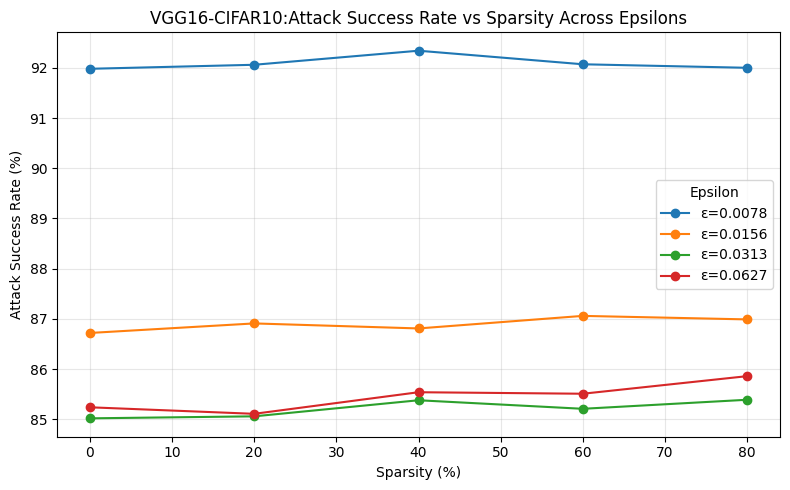

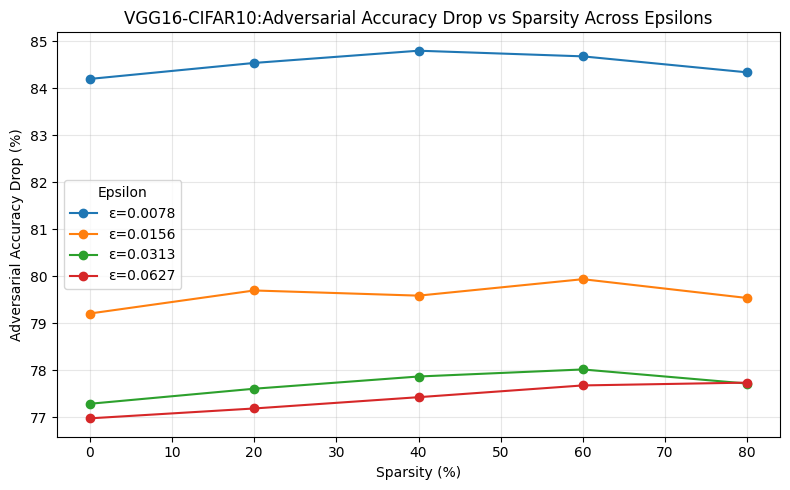

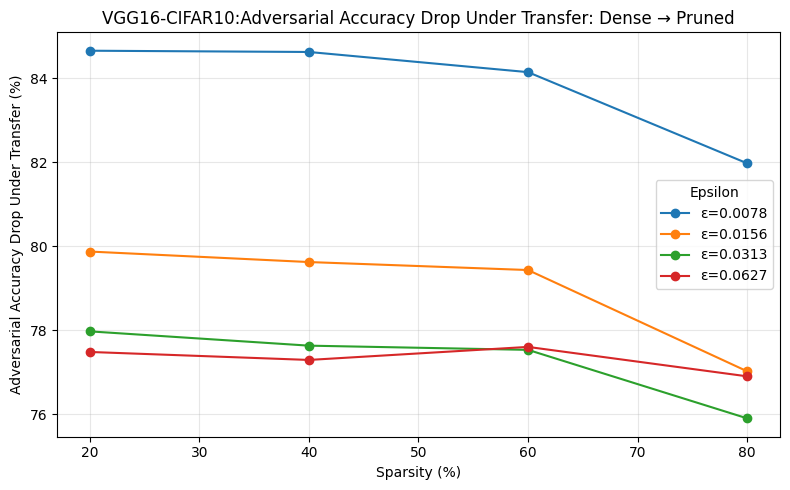

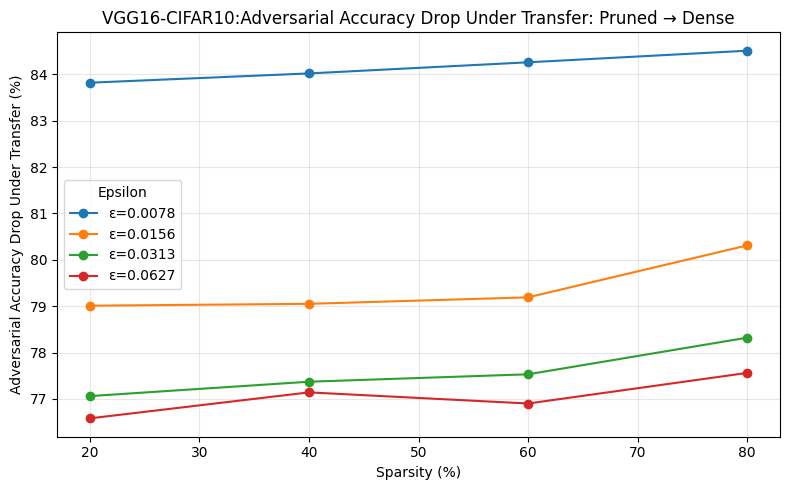

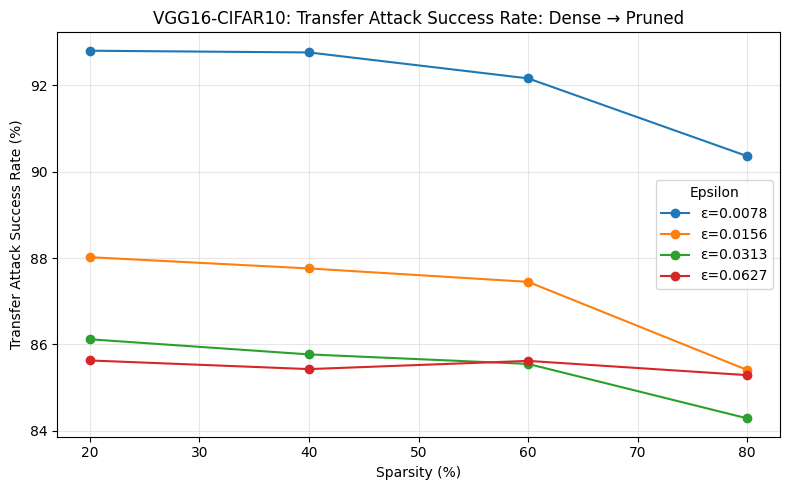

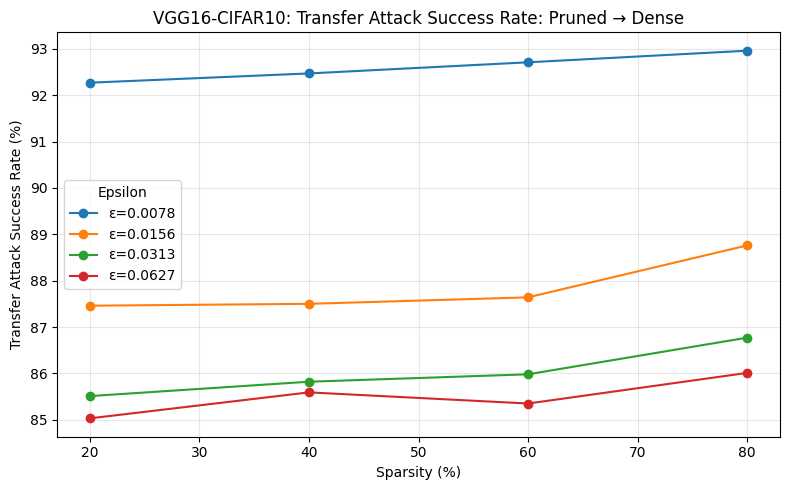

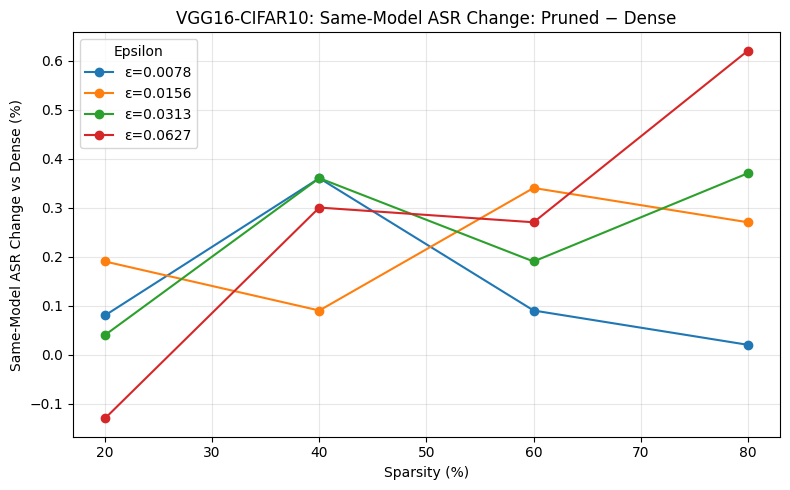

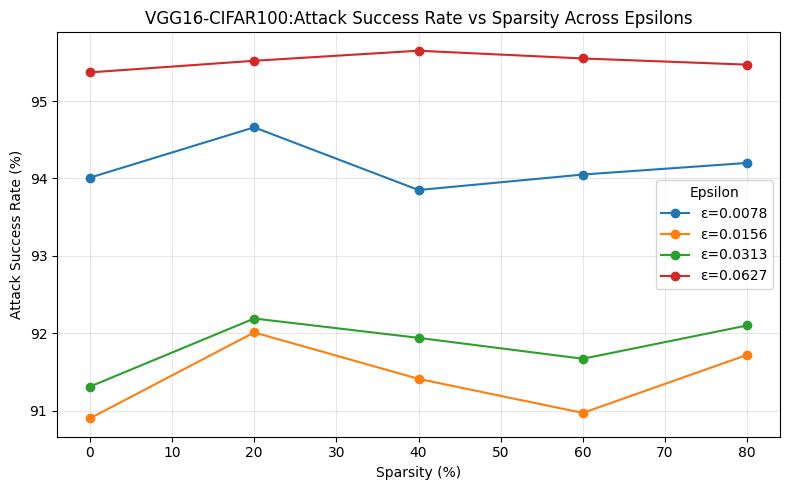

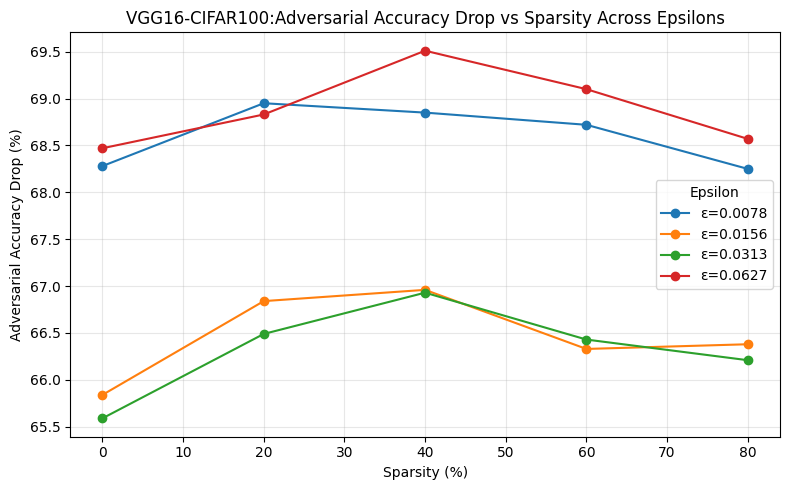

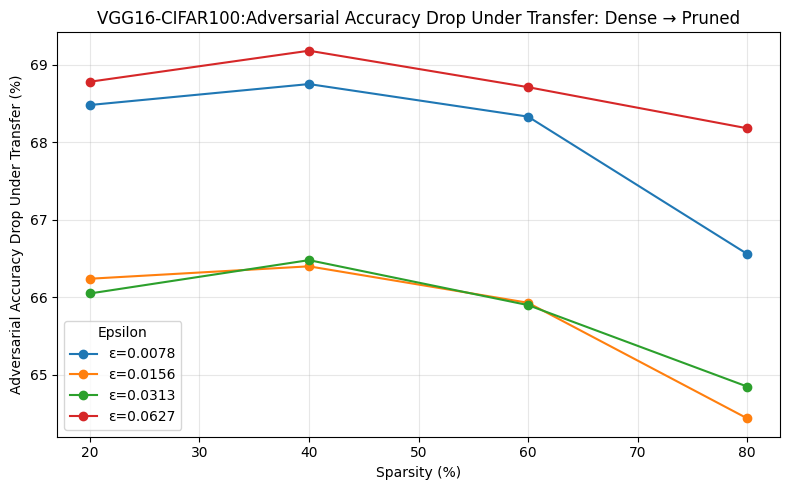

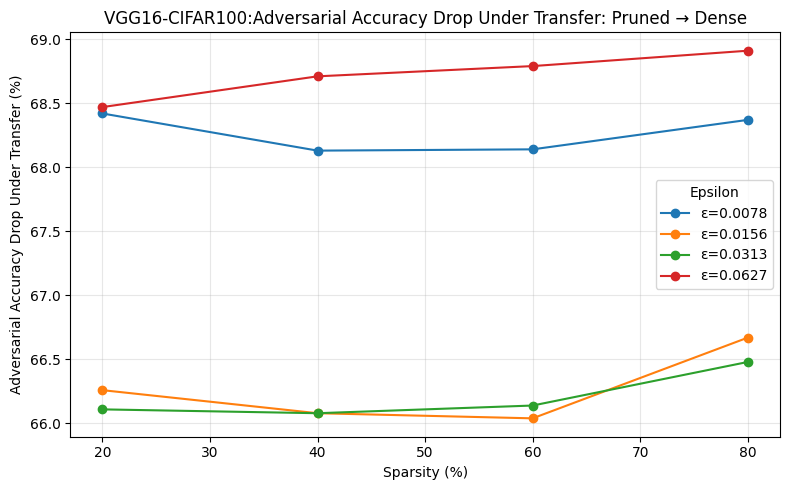

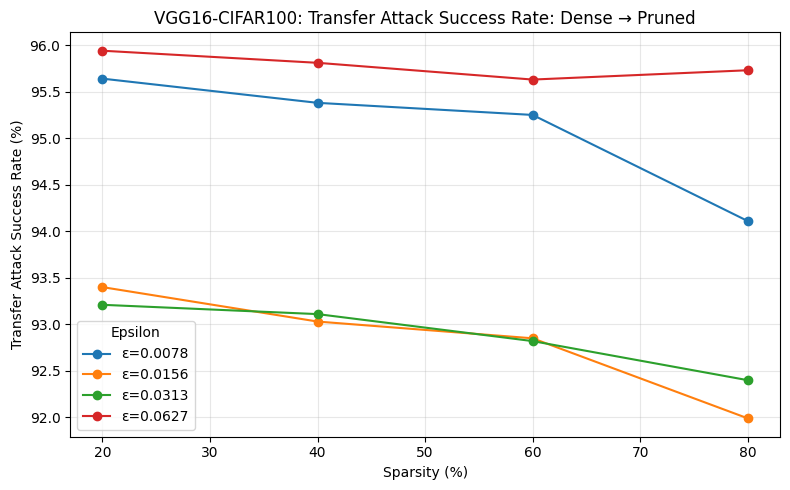

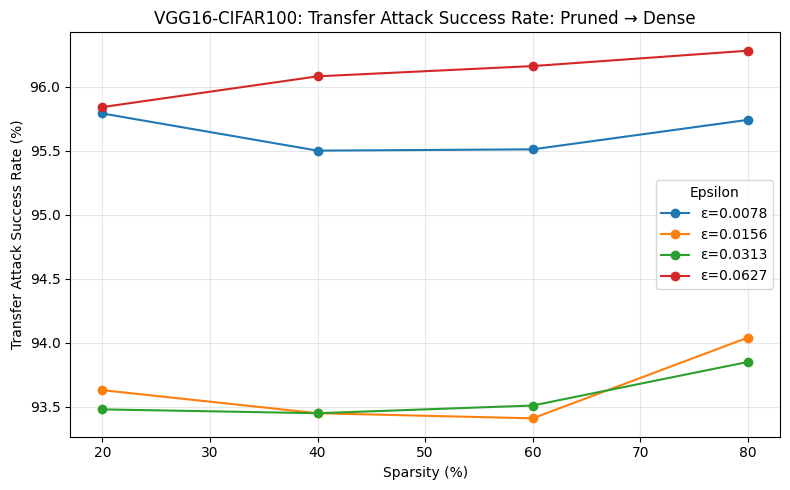

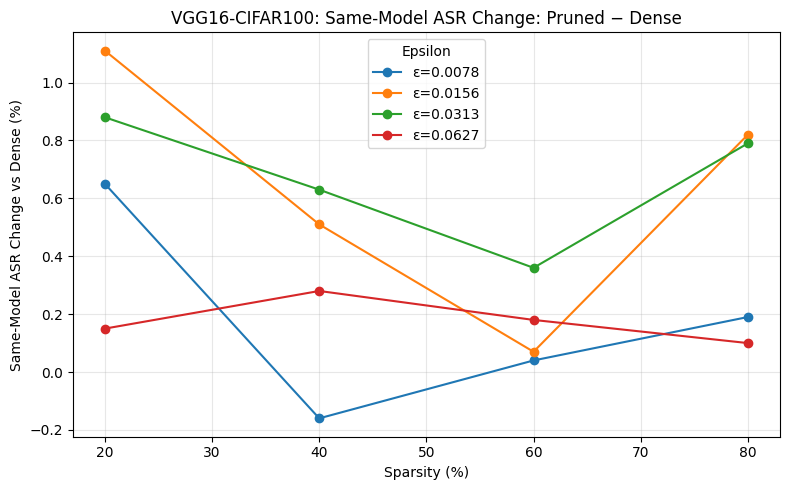

In [73]:
# -----------------------------
# Example usage
# -----------------------------

if __name__ == "__main__":
    models = ['VGG16']
    num_classes = ['10','100']
    for model in models:
        for num_class in num_classes:
            json_path = f"/content/drive/MyDrive/DLBA_Project/VGG_Result/{model}_T1_C{num_class}_result.json"

            attack_df, drop_df = make_plots(
                json_path=json_path,
                model_name=model,
                dataset_name=f"CIFAR{num_class}",
                output_dir="plots"
            )

            make_transfer_plots(
              json_path=json_path,
              model_name=model,
              dataset_name=f"CIFAR{num_class}",
              output_dir="plots"
            )

            make_same_model_asr_change_plot(
              json_path=json_path,
              model_name=model,
              dataset_name=f"CIFAR{num_class}",
              output_dir="plots",
            )